In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from keras.models import Sequential
from keras.layers import Dense, Dropout
from keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

In [8]:
df = pd.read_csv('boston_housing.csv')
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [10]:
x = df.drop('MEDV', axis=1)
y = df['MEDV']

In [11]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(x)
X_scaled[:5]

array([[-0.41978194,  0.28482986, -1.2879095 , -0.27259857, -0.14421743,
         0.41235069, -0.12001342,  0.1402136 , -0.98284286, -0.66660821,
        -1.45900038,  0.44105193, -1.0755623 ],
       [-0.41733926, -0.48772236, -0.59338101, -0.27259857, -0.74026221,
         0.19387449,  0.36716642,  0.55715988, -0.8678825 , -0.98732948,
        -0.30309415,  0.44105193, -0.49243937],
       [-0.41734159, -0.48772236, -0.59338101, -0.27259857, -0.74026221,
         1.27774347, -0.26581176,  0.55715988, -0.8678825 , -0.98732948,
        -0.30309415,  0.39642699, -1.2087274 ],
       [-0.41675042, -0.48772236, -1.30687771, -0.27259857, -0.83528384,
         1.01245093, -0.80988851,  1.07773662, -0.75292215, -1.10611514,
         0.1130321 ,  0.41616284, -1.36151682],
       [-0.41248185, -0.48772236, -1.30687771, -0.27259857, -0.83528384,
         1.22383375, -0.51117971,  1.07773662, -0.75292215, -1.10611514,
         0.1130321 ,  0.44105193, -1.02650148]])

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, 
    y,
    test_size=0.3,
    random_state=42
)

In [13]:
print('Training set shape:', X_train.shape, y_train.shape)
print('Testing set shape:', X_test.shape, y_test.shape)

Training set shape: (354, 13) (354,)
Testing set shape: (152, 13) (152,)


In [15]:
# Define model
model = Sequential()
model.add(Dense(64, input_dim=x.shape[1], activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(32, activation='relu'))
model.add(Dense(1)) # Output Layer

In [16]:
print(model.summary())

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 64)                896       
                                                                 
 dropout (Dropout)           (None, 64)                0         
                                                                 
 dense_1 (Dense)             (None, 32)                2080      
                                                                 
 dense_2 (Dense)             (None, 1)                 33        
                                                                 
Total params: 3009 (11.75 KB)
Trainable params: 3009 (11.75 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________
None


In [17]:
model.compile(loss='mean_squared_error', optimizer='adam', metrics=['mean_absolute_error'])

In [18]:
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [20]:
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/100


9/9 [==============================] - 2s 39ms/step - loss: 621.8406 - mean_absolute_error: 23.0242 - val_loss: 585.1773 - val_mean_absolute_error: 22.7051
Epoch 2/100
9/9 [==============================] - 0s 8ms/step - loss: 622.6194 - mean_absolute_error: 23.0256 - val_loss: 583.2851 - val_mean_absolute_error: 22.6634
Epoch 3/100
9/9 [==============================] - 0s 9ms/step - loss: 620.6869 - mean_absolute_error: 22.9834 - val_loss: 581.3493 - val_mean_absolute_error: 22.6206
Epoch 4/100
9/9 [==============================] - 0s 9ms/step - loss: 618.7231 - mean_absolute_error: 22.9400 - val_loss: 579.3464 - val_mean_absolute_error: 22.5763
Epoch 5/100
9/9 [==============================] - 0s 10ms/step - loss: 616.6373 - mean_absolute_error: 22.8951 - val_loss: 577.2800 - val_mean_absolute_error: 22.5305
Epoch 6/100
9/9 [==============================] - 0s 9ms/step - loss: 614.4874 - mean_absolute_error: 22.8481 - val_loss: 575.0801 - val_mean_absolute_error: 22

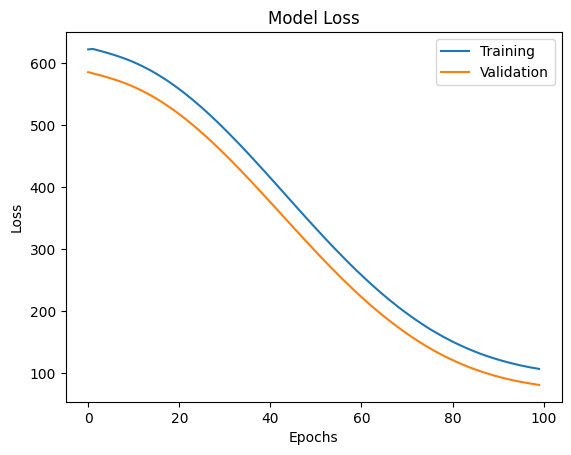

In [21]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(['Training', 'Validation'])
plt.show()

In [22]:
loss, mae = model.evaluate(X_test, y_test, verbose=0)
print(f"Loss, MAE: {loss}, {mae}")

Loss, MAE: 78.38543701171875, 5.960256576538086
